<a href="https://colab.research.google.com/github/iamvarshag/Bio-infomatics/blob/Bioinfoexp/Design%2C_Implement_and_Execute_Python_based_Workflow_for_Phylogenetic_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython
!apt-get install -y mafft



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-lato libauthen-sasl-perl libclone-perl libdata-dump-perl
  libencode-locale-perl libfile-listing-perl libfont-afm-perl
  libhtml-form-perl libhtml-format-perl libhtml-parser-perl
  libhtml-tagset-perl libhtml-tree-perl libhttp-cookies-perl
  libhttp-daemon-perl libhttp-date-perl libhttp-message-perl
  libhttp-negotiate-perl libio-html-perl libio-socket-ssl-perl
  liblwp-mediatypes-perl liblwp-protocol-https-perl libmailtools-perl
  libnet-http-perl libnet-smtp-ssl-perl libnet-ssleay-perl libruby3.0
  libtry-tiny-perl liburi-perl libwww-perl libwww-robotrules-perl lynx
  lynx-common netbase perl-openssl-defaults rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration
Suggested packages:
  libdigest-hmac-perl libgssap

In [ ]:
from Bio import Entrez, SeqIO

Entrez.email = "your_email@gmail.com"   # REQUIRED by NCBI

animals = {
    "Human": "NP_000198.1",
    "Cow": "NP_776983.1",
    "Pig": "NP_999205.1",
    "Sheep": "NP_001009292.1",
    "Dog": "NP_001003241.1",
    "Cat": "NP_001009874.1",
    "Rat": "NP_037197.1",
    "Mouse": "NP_032401.1"
}

with open("sequences.fasta", "w") as output:
    for animal, acc in animals.items():
        handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
        record.id = animal
        record.description = ""
        SeqIO.write(record, output, "fasta")
        handle.close()

print("✔ Insulin sequences downloaded and saved as sequences.fasta")


✔ Insulin sequences downloaded and saved as sequences.fasta


In [ ]:
import subprocess
from Bio import AlignIO

# Instead of MafftCommandline, use subprocess to run mafft directly
mafft_command = ["mafft", "--auto", "sequences.fasta"]
process = subprocess.run(mafft_command, capture_output=True, text=True, check=True)
stdout = process.stdout
# stderr can be captured in process.stderr if needed for debugging

with open("aligned.fasta", "w") as handle:
    handle.write(stdout)

alignment = AlignIO.read("aligned.fasta", "fasta")
print("✔ Alignment completed and saved as aligned.fasta")

✔ Alignment completed and saved as aligned.fasta



UPGMA Tree:
  ______________________________________________________________________ Pig
_|
 |                ______________________________________________________ Cow
 |_______________|
                 |   ___________________________________________________ Rat
                 |__|
                    |      _____________________________________________ Sheep
                    |_____|
                          |              _______________________________ Cat
                          |_____________|
                                        |     __________________________ Dog
                                        |____|
                                             |  ________________________ Mouse
                                             |_|
                                               |________________________ Human



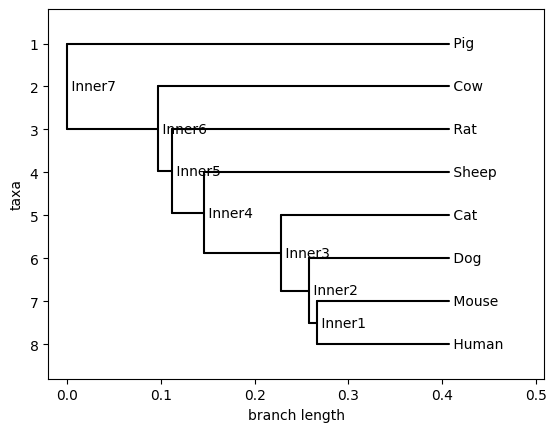


Neighbor Joining Tree:
   _______________ Dog
 ,|
 ||________________ Human
 |
 |     __________________________________ Sheep
 |____|
 |    |    _________________________________ Rat
_|    |___|
 |        |  ___________________________________________________________ Pig
 |        |_|
 |          |___________________________________ Cow
 |
 |  ______________ Mouse
 |_|
   |____________________ Cat



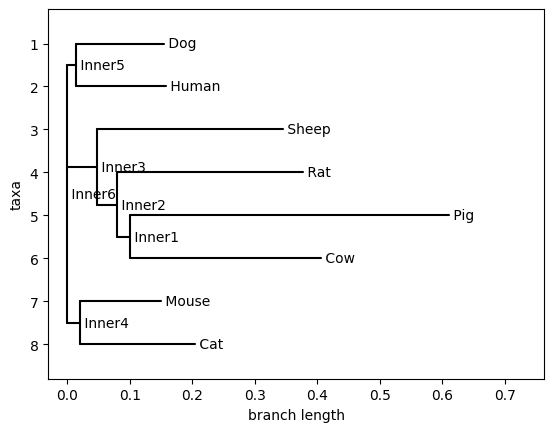

In [ ]:
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

# Distance matrix
calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)

# Tree constructor
constructor = DistanceTreeConstructor()

# UPGMA Tree
upgma_tree = constructor.upgma(distance_matrix)
print("\nUPGMA Tree:")
Phylo.draw_ascii(upgma_tree)
Phylo.draw(upgma_tree)

# Neighbor Joining Tree
nj_tree = constructor.nj(distance_matrix)
print("\nNeighbor Joining Tree:")
Phylo.draw_ascii(nj_tree)
Phylo.draw(nj_tree)
